In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , LabelEncoder , OneHotEncoder

from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score 

In [2]:
data = pd.read_csv("../data/cleaned/processing.csv")

In [3]:
data.head()

,Age,Gender,Branch,Division,GHQ,Depression,Anxiety,Stress,BRS,Depression_Level,Anxiety_Level,Stress_Level,BRS_Level,Cluster
0,19,Male,Computer Science,J,21,16,12,16,2.33,Moderate,Moderate,Mild,Low,D
1,17,Female,CSE(Artificial Intelligence),F,18,14,18,10,1.83,Moderate,Severe/Extremely Severe,Normal,Low,F
2,18,Male,Computer Science,E,9,0,0,0,0.00,Normal,Normal,Normal,Balanced wellbeing,A
3,18,Male,Mechanical Engineering,B,10,0,0,0,0.00,Normal,Normal,Normal,Balanced wellbeing,A
4,18,Male,Artificial Intelligence and Data Science,D,3,0,0,0,0.00,Normal,Normal,Normal,Balanced wellbeing,A


In [4]:
data["Depression_Level"].value_counts()

Depression_Level
Normal                     2559
Moderate                    330
Mild                        202
Severe/Extremely Severe     167
Name: count, dtype: int64

In [5]:
features = ["Gender",
            "GHQ",
            "Depression",
            "Anxiety",
            "Stress",
            "BRS"
           ]


In [6]:
X = data[features]
Y = data["Cluster"]

In [7]:
X.head()

,Gender,GHQ,Depression,Anxiety,Stress,BRS
0,Male,21,16,12,16,2.33
1,Female,18,14,18,10,1.83
2,Male,9,0,0,0,0.00
3,Male,10,0,0,0,0.00
4,Male,3,0,0,0,0.00


In [8]:
le = LabelEncoder()
Y = le.fit_transform(Y)

In [9]:
joblib.dump(le,
           "../Models/label_encoder.pkl")

['../Models/label_encoder.pkl']

In [10]:
num_cols = X.select_dtypes(["int","float"]).columns
cat_cols = X.select_dtypes("object").columns

In [11]:
num_cols

Index(['GHQ', 'Depression', 'Anxiety', 'Stress', 'BRS'], dtype='object')

In [12]:
num_transformer = Pipeline([
    ("scaler",StandardScaler())   
])

cat_transformer = Pipeline([
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num",num_transformer,num_cols),
    ("cat",cat_transformer,cat_cols)
])
joblib.dump(preprocessor,"../models/preprocessor.pkl")

['../models/preprocessor.pkl']

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [15]:
X_train

,Gender,GHQ,Depression,Anxiety,Stress,BRS
790,Male,12,4,0,0,3.0
1071,Female,14,14,12,2,3.0
2460,Female,8,0,0,0,0.0
282,Female,6,0,0,0,0.0
723,Male,8,0,0,0,0.0
...,...,...,...,...,...,...
2282,Male,6,0,0,0,0.0
1622,Female,10,0,0,0,0.0
958,Male,12,2,6,2,4.0
194,Male,19,6,0,0,3.0


# Logistic Regression 

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# model = LogisticRegression(max_iter=5000,random_state=42)
# model.fit(X_tr,Y_train)
# y_pred = model.predict(X_ts)

In [18]:
# lr = Pipeline([
#     ("prep",preprocessor),
#     ("model",LogisticRegression(
#         max_iter=5000,
#         random_state=42
#     )
#     )
# ])
lr = LogisticRegression(max_iter=5000,random_state=42)
lr.fit(X_train_processed,Y_train)
# joblib.dump(lr,"../Models/Logistic_Regression.pkl")

['../Models/Logistic_Regression.pkl']

In [19]:
y_pred_lr = lr.predict(X_test_processed)
y_pred_tr = lr.predict(X_train_processed)

### Logistic Regression Metrics

In [20]:
print("Accuracy Score: ",accuracy_score(Y_test,y_pred_lr))
print("Recall Score: ",recall_score(Y_test,y_pred_lr,average="macro"))
print("Precision Score: ",precision_score(Y_test,y_pred_lr,average="macro"))

# recall_score is very low as some cluster has small samples 

Accuracy Score:  0.9401840490797546
Recall Score:  0.6710918559447971
Precision Score:  0.7373548830202056


C:\Users\irg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
print(pd.DataFrame(Y_train).value_counts().sort_index())
print(pd.DataFrame(Y_test).value_counts().sort_index())

0
0    1721
1     199
2     146
3     221
4       3
5     205
6      53
7      58
Name: count, dtype: int64
0
0    430
1     50
2     37
3     55
4      1
5     51
6     13
7     15
Name: count, dtype: int64


# KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [23]:
X_train_processed = preprocessor.fit_transform(X_train) 
X_test_processed = preprocessor.transform(X_test) 

### n_neighbors vs Recall score

In [24]:
neighbors = [2,3,4,5,6,7,8,9,10]
recallscore = []
for n in neighbors:
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train_processed,Y_train)
    y_pred_kn = model.predict(X_test_processed)
    prediction = recall_score(Y_test,y_pred_kn,average="macro")
    recallscore.append(prediction) 
    print(f"N_neighbors: {n}----Recall Score: {prediction}")

N_neighbors: 2----Recall Score: 0.5603114426643838
N_neighbors: 3----Recall Score: 0.5886639724875019
N_neighbors: 4----Recall Score: 0.6047940268528504
N_neighbors: 5----Recall Score: 0.6068020519491107
N_neighbors: 6----Recall Score: 0.5684833846598552
N_neighbors: 7----Recall Score: 0.5946594476006241
N_neighbors: 8----Recall Score: 0.6013012292424057
N_neighbors: 9----Recall Score: 0.5828346137169667
N_neighbors: 10----Recall Score: 0.5718720468720468


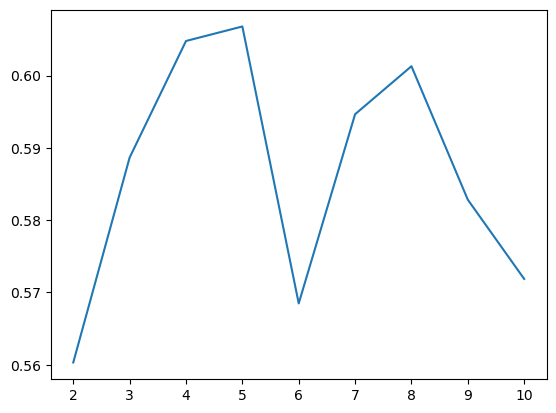

In [25]:
import matplotlib.pyplot as plt 
plt.plot(neighbors,recallscore)
plt.savefig("../reports/KNN_recall_vs_neighbors")

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed,Y_train)
y_pred_knn = knn.predict(X_test_processed)

In [27]:
print("Accuracy Score: ",accuracy_score(Y_test,y_pred_knn))
print("Recall Score: ",recall_score(Y_test,y_pred_knn,average="macro"))

Accuracy Score:  0.911042944785276
Recall Score:  0.6068020519491107


# Descision Trees

In [28]:
from sklearn.tree import DecisionTreeClassifier

### max_depth vs Recall Score

In [29]:
depth = [8,9,10,13,15,18,19,20,23,25]
dep_prediction =[]
for dep in depth:
    temp_model = DecisionTreeClassifier(max_depth=dep)
    temp_model.fit(X_train_processed,Y_train)
    y_pred = temp_model.predict(X_test_processed)
    prediction = recall_score(Y_test,y_pred,average="macro")
    dep_prediction.append(prediction)
    print(f"Depth : {dep}-----Recall Score: {prediction}")

Depth : 8-----Recall Score: 0.8727272727272728
Depth : 9-----Recall Score: 0.8643939393939395
Depth : 10-----Recall Score: 0.8727272727272728
Depth : 13-----Recall Score: 0.8643939393939395
Depth : 15-----Recall Score: 0.8643939393939395
Depth : 18-----Recall Score: 0.8643939393939395
Depth : 19-----Recall Score: 0.8727272727272728
Depth : 20-----Recall Score: 0.8727272727272728
Depth : 23-----Recall Score: 0.8643939393939395
Depth : 25-----Recall Score: 0.8727272727272728


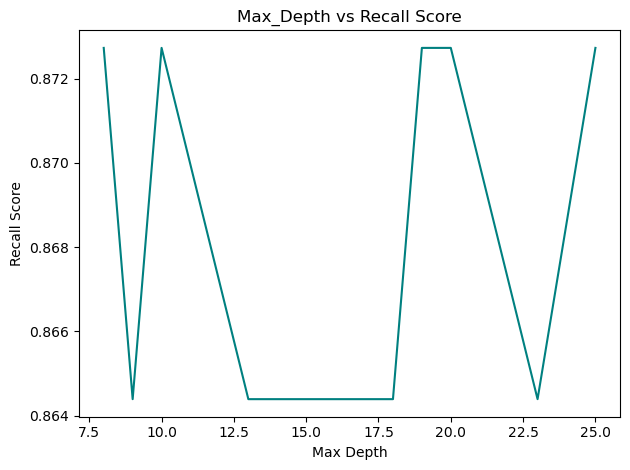

In [30]:
plt.plot(depth,dep_prediction,color = "teal")
plt.title("Max_Depth vs Recall Score")
plt.xlabel("Max Depth")
plt.ylabel("Recall Score")
plt.tight_layout()
plt.savefig("../reports/DT_Max_depth_vs_Recall_score")

### min_samples_split vs Recall Score

In [31]:
split = [4,5,6,7,8,9,12,13,14,15]
samples_split_recall = []
for sam in split:
    temp_model = DecisionTreeClassifier(min_samples_split=sam)
    temp_model.fit(X_train_processed,Y_train)
    y_pred = temp_model.predict(X_test_processed)
    prediction = recall_score(Y_test,y_pred,average="macro")
    samples_split_recall.append(prediction)
    print(f"Min_samples_split : {sam}-----Recall Score: {prediction}")

Min_samples_split : 4-----Recall Score: 0.8643939393939395
Min_samples_split : 5-----Recall Score: 0.8643939393939395
Min_samples_split : 6-----Recall Score: 0.8643939393939395
Min_samples_split : 7-----Recall Score: 0.8727272727272728
Min_samples_split : 8-----Recall Score: 0.8727272727272728
Min_samples_split : 9-----Recall Score: 0.8727272727272728
Min_samples_split : 12-----Recall Score: 0.8727272727272728
Min_samples_split : 13-----Recall Score: 0.8727272727272728
Min_samples_split : 14-----Recall Score: 0.8727272727272728
Min_samples_split : 15-----Recall Score: 0.8727272727272728


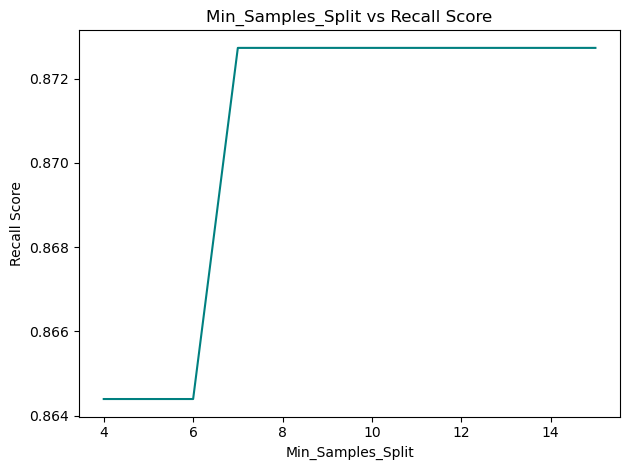

In [32]:
plt.plot(split,samples_split_recall,color = "teal")
plt.title("Min_Samples_Split vs Recall Score")
plt.xlabel("Min_Samples_Split")
plt.ylabel("Recall Score")
plt.tight_layout()
plt.savefig("../reports/DT_Min_samples_split_vs_Recall_score")

## Final Descision Tree Model 

In [33]:
dt = DecisionTreeClassifier(max_depth=10,min_samples_split=12)
dt.fit(X_train_processed,Y_train)
joblib.dump(dt,"../Models/Descision_Tree_CLassifier.pkl")
y_pred_dt = dt.predict(X_test_processed)

In [34]:
print("Accuracy Score: ",accuracy_score(Y_test,y_pred_dt))
print("F1 Score: ",f1_score(Y_test,y_pred_dt,average="macro"))
print("Recall Score: ",recall_score(Y_test,y_pred_dt,average="macro"))

Accuracy Score:  0.9969325153374233
F1 Score:  0.8705637373249637
Recall Score:  0.8727272727272728


# Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

### n_estimators vs Recall Score

In [36]:
estimators = [100,150,160,200,230,251,350,400]
score = []
for n in estimators:
    model = RandomForestClassifier(n_estimators=n,random_state=42)
    model.fit(X_train_processed,Y_train)
    y_pred = model.predict(X_test_processed)
    prediction = recall_score(Y_test,y_pred,average="macro")
    score.append(prediction)
    print(f"n_estimators: {n}----Recall Score: {prediction}")

n_estimators: 100----Recall Score: 0.8680035650623886
n_estimators: 150----Recall Score: 0.8680035650623886
n_estimators: 160----Recall Score: 0.8680035650623886
n_estimators: 200----Recall Score: 0.8704545454545455
n_estimators: 230----Recall Score: 0.8704545454545455
n_estimators: 251----Recall Score: 0.8704545454545455
n_estimators: 350----Recall Score: 0.8704545454545455
n_estimators: 400----Recall Score: 0.8704545454545455


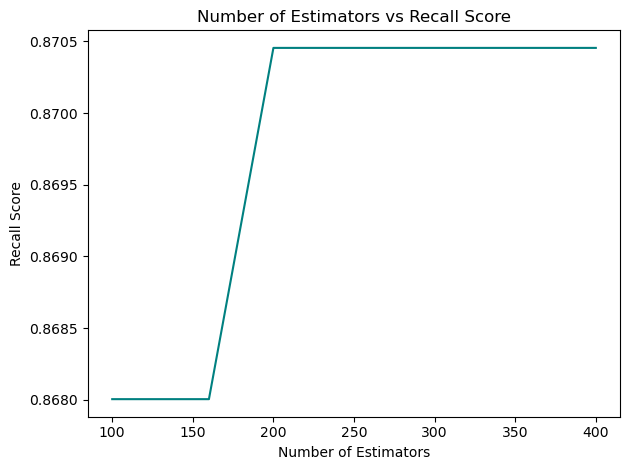

In [37]:
plt.plot(estimators,score,color = "teal")
plt.title("Number of Estimators vs Recall Score")
plt.xlabel("Number of Estimators")
plt.ylabel("Recall Score")
plt.tight_layout()
plt.savefig("../reports/RF_n_estimators_vs_Recall_score")

In [38]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train_processed,Y_train)
joblib.dump(rf,"../Models/Random_Forest_Classifier.pkl")
y_pred_rf = rf.predict(X_test_processed)
print("Recall Score: ",recall_score(Y_test,y_pred_rf,average="macro"))

Recall Score:  0.8704545454545455


# SVM 

In [39]:
from sklearn.svm import SVC

### C_Values vs Recall score

In [40]:
c_values = [5,6,17,19,23,25,26,27,35]
recall_c = []
for c in c_values:
    model = SVC(C=c)
    model.fit(X_train_processed,Y_train)
    y_pred = model.predict(X_test_processed)
    score = recall_score(Y_test,y_pred,average="macro")
    recall_c.append(score)
    print(f"C : {c}----Recall Score: {score}")

C : 5----Recall Score: 0.7317540699893641
C : 6----Recall Score: 0.7400874033226974
C : 17----Recall Score: 0.7655694371870843
C : 19----Recall Score: 0.7655694371870843
C : 23----Recall Score: 0.796221367397838
C : 25----Recall Score: 0.796221367397838
C : 26----Recall Score: 0.8058367520132226
C : 27----Recall Score: 0.8058367520132226
C : 35----Recall Score: 0.8069424031188737


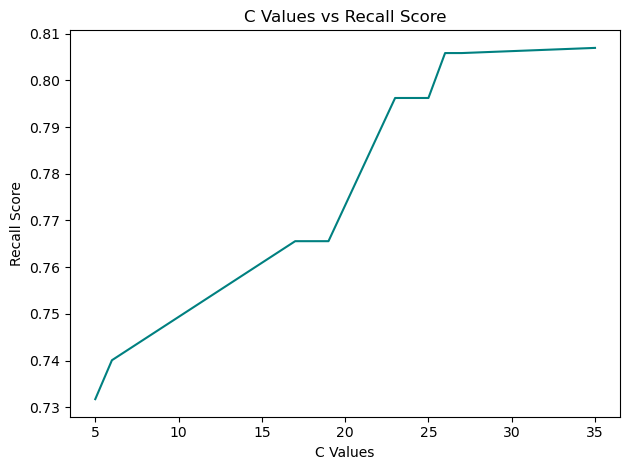

In [41]:
plt.plot(c_values,recall_c,color = "teal")
plt.title("C Values vs Recall Score")
plt.xlabel("C Values")
plt.ylabel("Recall Score")
plt.tight_layout()
plt.savefig("../reports/SVM_C_Values_vs_Recall_score")

### Kernels vs Recall score

In [42]:
kernels = ["linear","rbf","sigmoid","poly"]
recall_kernel = []
for c in kernels:
    model = SVC(kernel=c,C=26)
    model.fit(X_train_processed,Y_train)
    y_pred = model.predict(X_test_processed)
    score = recall_score(Y_test,y_pred,average="macro")
    recall_kernel.append(score)
    print(f"Kernel : {c}----Recall Score: {score}")

Kernel : linear----Recall Score: 0.7968117243117243
Kernel : rbf----Recall Score: 0.8058367520132226
Kernel : sigmoid----Recall Score: 0.34017134164192986
Kernel : poly----Recall Score: 0.7832236298412769


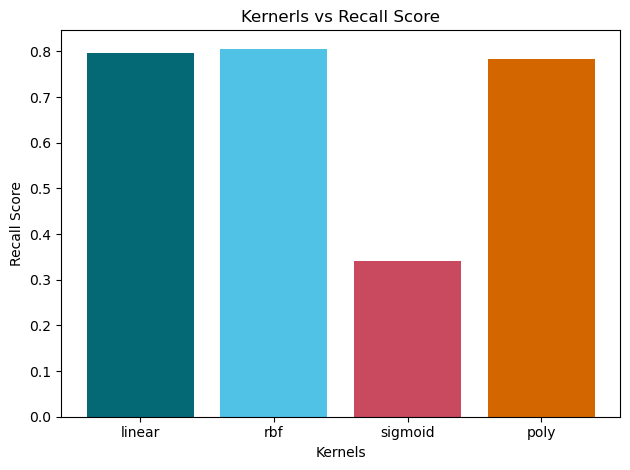

In [43]:
plt.bar(kernels,recall_kernel,color=["#056875","#50C2E5","#C9495E","#D46600"])
plt.title("Kernerls vs Recall Score")
plt.xlabel("Kernels")
plt.ylabel("Recall Score")
plt.tight_layout()
plt.savefig("../reports/SVM_kernels_vs_Recall_score")

### final model

In [44]:
svc_model = SVC(C=26,kernel="rbf")
svc_model.fit(X_train_processed,Y_train)
joblib.dump(model,"../Models/SVM_Classifier.pkl")
y_pred_svc = svc_model.predict(X_test_processed)
print(recall_score(Y_test,y_pred_svc,average="macro"))

0.8058367520132226


# Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

In [46]:
xgb = GradientBoostingClassifier(learning_rate=0.1,n_estimators=200)
xgb.fit(X_train_processed,Y_train)
joblib.dump(xgb,"../Models/Gradient_Boosting_Classifier.pkl")
y_pred_gb = xgb.predict(X_test_processed)
print(recall_score(Y_test,y_pred_gb,average="macro"))

0.875


# Evaluation Metrics Comparision

In [47]:
import sys
import os

# for moving outside the sub folder 
sys.path.append(os.path.abspath(".."))


In [48]:
from src.evaluation import evaluate_model

In [56]:
results = []

for name, model in {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    "SVM":svc_model,
    'XGBoost': xgb
}.items():

    model.fit(
        X_train_processed,
        Y_train
    )

    scores = evaluate_model(
        model,
        X_test_processed,
        Y_test
    )

    scores['Model'] = name
    results.append(scores)

results = pd.DataFrame(results)

results=results[["Model","Accuracy","Precision","Recall","F1"]]

C:\Users\irg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\irg\anaconda3\Lib\site-packages\sklea

In [58]:
results.to_csv("../reports/Evaluation_Metrics_Table.csv",index=False)